
# Random Forest Classifier

## Step 1 - Import Libraries

In [19]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)


## Step 2 - Load Iris Dataset

In [20]:

iris = load_iris()

X = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

y = iris.target

print(X.head())


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


## Step 3 - Understand Dataset

In [21]:

print("Feature Shape :", X.shape)
print("Target Shape  :", y.shape)

print("\nTarget Names")
print(iris.target_names)


Feature Shape : (150, 4)
Target Shape  : (150,)

Target Names
['setosa' 'versicolor' 'virginica']


## Step 4 - Train Test Split

In [22]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

print(X_train.shape)
print(X_test.shape)


(120, 4)
(30, 4)


## Step 5 - Create Random Forest Classifier

In [23]:

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model


RandomForestClassifier(random_state=42)

## Step 6 - Train Model

In [24]:

model.fit(
    X_train,
    y_train
)

print("Model Trained Successfully")


Model Trained Successfully


## Step 7 - Make Predictions

In [25]:

predictions = model.predict(X_test)

print(predictions)


[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


## Step 8 - Accuracy Score

In [26]:

accuracy = accuracy_score(
    y_test,
    predictions
)

print("Accuracy:", accuracy)


Accuracy: 1.0


## Step 9 - Confusion Matrix

In [27]:

cm = confusion_matrix(
    y_test,
    predictions
)

print(cm)


[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


## Step 10 - Classification Report

In [28]:

print(
    classification_report(
        y_test,
        predictions
    )
)


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## Step 11 - OOB Score (Out-of-Bag Evaluation)

In [29]:

oob_model = RandomForestClassifier(
    n_estimators=100,
    oob_score=True,
    random_state=42
)

oob_model.fit(
    X_train,
    y_train
)

print("OOB Score:", oob_model.oob_score_)


OOB Score: 0.9166666666666666


## Step 12 - Feature Importance

In [30]:

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance.sort_values(
    by='Importance',
    ascending=False
)


,Feature,Importance
2,petal length (cm),0.439994
3,petal width (cm),0.421522
0,sepal length (cm),0.108098
1,sepal width (cm),0.030387


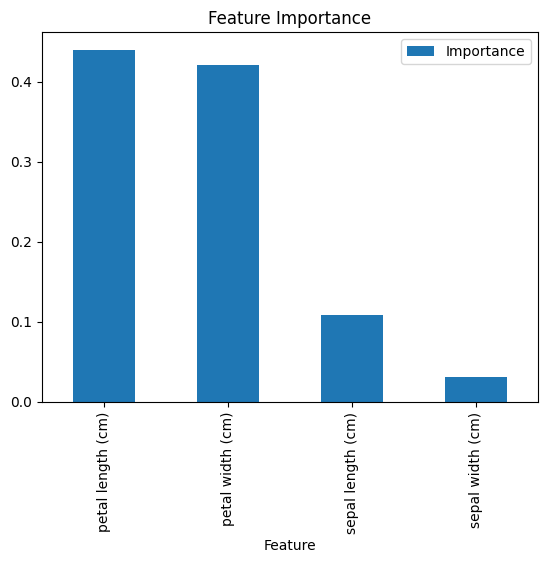

In [31]:

importance.sort_values(
    by='Importance',
    ascending=False
).plot(
    x='Feature',
    y='Importance',
    kind='bar'
)

plt.title("Feature Importance")

plt.show()


## Step 13 - Compare Number of Trees

In [32]:

tree_counts = [1, 5, 10, 50, 100, 200]

results = []

for trees in tree_counts:

    rf = RandomForestClassifier(
        n_estimators=trees,
        random_state=42
    )

    rf.fit(X_train, y_train)

    pred = rf.predict(X_test)

    acc = accuracy_score(
        y_test,
        pred
    )

    results.append(acc)

comparison = pd.DataFrame({
    'Trees': tree_counts,
    'Accuracy': results
})

comparison


,Trees,Accuracy
0,1,1.000000
1,5,0.966667
2,10,1.000000
3,50,1.000000
4,100,1.000000
5,200,1.000000


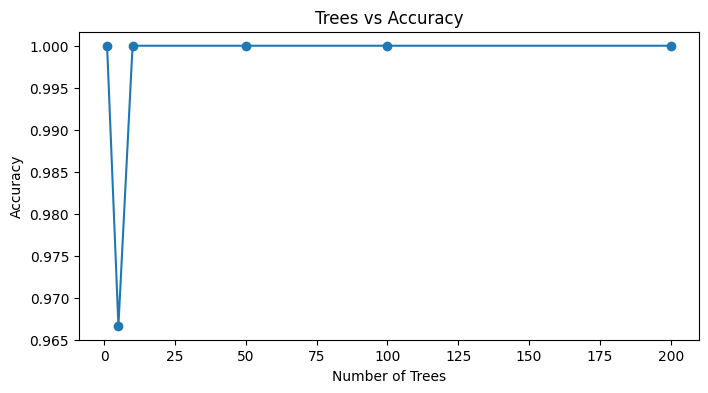

In [33]:

plt.figure(figsize=(8,4))

plt.plot(
    tree_counts,
    results,
    marker='o'
)

plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")

plt.title("Trees vs Accuracy")

plt.show()


## Step 14 - Hyperparameter Tuning Example

In [34]:

tuned_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42
)

tuned_model.fit(
    X_train,
    y_train
)

tuned_pred = tuned_model.predict(
    X_test
)

print(
    "Tuned Accuracy:",
    accuracy_score(
        y_test,
        tuned_pred
    )
)


Tuned Accuracy: 1.0


## Step 15 - Predict New Flower

In [35]:

sample = [[
    5.1,
    3.5,
    1.4,
    0.2
]]

prediction = model.predict(sample)

species = iris.target_names[
    prediction[0]
]

print("Predicted Species:", species)


Predicted Species: setosa


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
